# EDA rápido — los datos que ven los modelos

El [EDA del panel](eda_panel_union.ipynb) explora los datos **crudos**; este notebook
mira lo que sale del **pipeline** (`data.prepare` → `build_crop_dataset`): las matrices
normalizadas por departamento con las que se entrena y evalúa cada experimento de
`experiments/`. Chequeos: tamaños y balance por split, sanidad de la normalización,
exclusiones del train, y el *distribution shift* visto en los datos finales.

> **Solo train/test.** No hay split de validación: se probó un val 2018–2020 y resultó
> **ciego** (sus anomalías son de años sin sequía grande, sin firma climática → PR-AUC
> ≈ tasa base, no discrimina modelos), así que se pliega al train (`CropDataset` no
> tiene `X_val`/`y_val`; ver `experiments/01`).

In [ ]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == "eda":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

from src import data as cdata

panel_z = cdata.prepare()
ds = {c: cdata.build_crop_dataset(panel_z, c) for c in ["soja", "maiz"]}

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


## 1 · Tamaños, balance y exclusiones
El train es **solo campañas normales** (se excluyen anomalías, años con >30% de
departamentos anómalos, y el bloque de val plegado); el test queda intacto con su
etiqueta.

In [ ]:
filas = []
for c, d in ds.items():
    filas.append({
        "cultivo": c, "features": len(d.feature_cols),
        "train_normal": len(d.X_train),
        "test": len(d.X_test), "anom_test": int(d.y_test.sum()),
        "tasa_test_%": round(d.y_test.mean()*100, 1),
        "excl_por_año": d.n_excluded_year, "excl_por_anomalía": d.n_excluded_anom})
pd.DataFrame(filas).set_index("cultivo")

,features,train_normal,test,anom_test,tasa_test_%,excl_por_año,excl_por_anomalía
cultivo,,,,,,,
soja,72,6142,942,251,26.6,837,572
maiz,72,8082,1160,345,29.7,1113,483


## 2 · Sanidad de la normalización
Cada feature se z-scorea **por departamento con estadísticas del train normal**. En
train, media ≈ 0 y desvío ≈ 1 por construcción; en test los corrimientos son reales
(clima distinto), no bugs. Y no debe haber NaN/Inf.

In [ ]:
for c, d in ds.items():
    for nombre, X in [("train", d.X_train), ("test", d.X_test)]:
        print(f"{c:5s} {nombre:5s}  media={X.mean():+.3f}  std={X.std():.3f}  "
              f"finitos={np.isfinite(X).all()}")

soja  train  media=+0.003  std=0.977  finitos=True
soja  test   media=+0.189  std=1.330  finitos=True
maiz  train  media=+0.005  std=0.980  finitos=True
maiz  test   media=+0.204  std=1.327  finitos=True


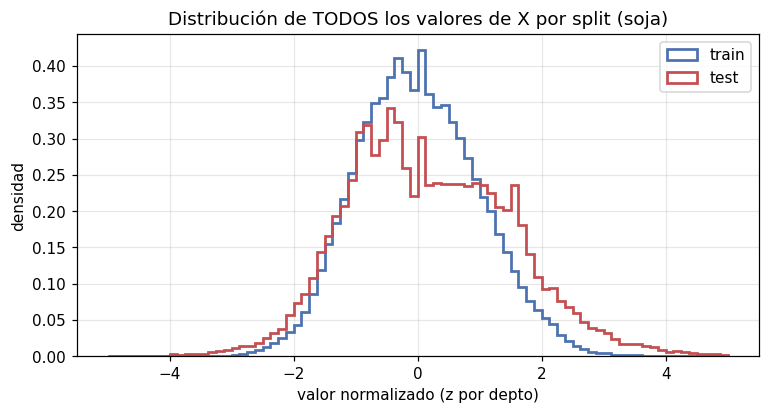

In [4]:
d = ds["soja"]
fig, ax = plt.subplots(figsize=(8, 3.8))
for nombre, X, color in [("train", d.X_train, "#4C72B0"), ("test", d.X_test, "#C44E52")]:
    ax.hist(X.ravel(), bins=80, range=(-5, 5), density=True, histtype="step",
            lw=1.8, color=color, label=nombre)
ax.set_xlabel("valor normalizado (z por depto)"); ax.set_ylabel("densidad")
ax.set_title("Distribución de TODOS los valores de X por split (soja)")
ax.legend(); ax.grid(alpha=0.3); plt.show()

## 3 · El *distribution shift* train→test, feature por feature
Media de cada feature en test (en unidades de desvío del train). Lo que esté lejos de
0 es clima sistemáticamente distinto al período de entrenamiento:

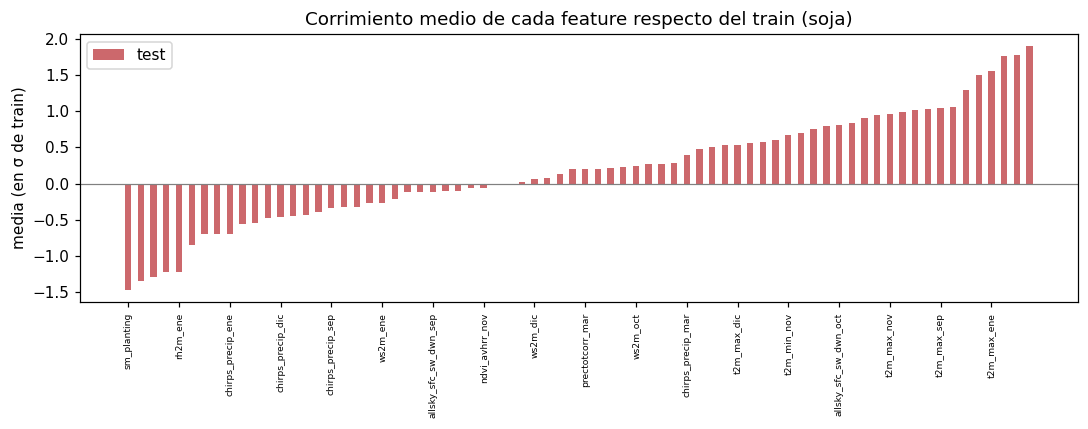

test — features más corridas:
sm_planting   -1.47
sm_winter     -1.36
rh2m_oct      -1.29
t2m_max_feb    1.77
t2m_ene        1.78
t2m_feb        1.90


In [5]:
d = ds["soja"]
mt = d.X_test.mean(axis=0)
orden = np.argsort(mt)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(orden))
ax.bar(x, mt[orden], 0.5, label="test", color="#C44E52", alpha=0.85)
paso = 4
ax.set_xticks(x[::paso])
ax.set_xticklabels([d.feature_cols[i] for i in orden[::paso]], rotation=90, fontsize=6)
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylabel("media (en σ de train)"); ax.legend()
ax.set_title("Corrimiento medio de cada feature respecto del train (soja)")
plt.tight_layout(); plt.show()
ext = pd.Series(mt, index=d.feature_cols).sort_values()
print("test — features más corridas:")
print(pd.concat([ext.head(3), ext.tail(3)]).round(2).to_string())

## 4 · ¿Qué separa a las anomalías en los datos finales? (test, soja)
Diferencia de medias (anómalas − normales) por feature, en el espacio normalizado que
ven los modelos — el "mapa de señal" disponible:

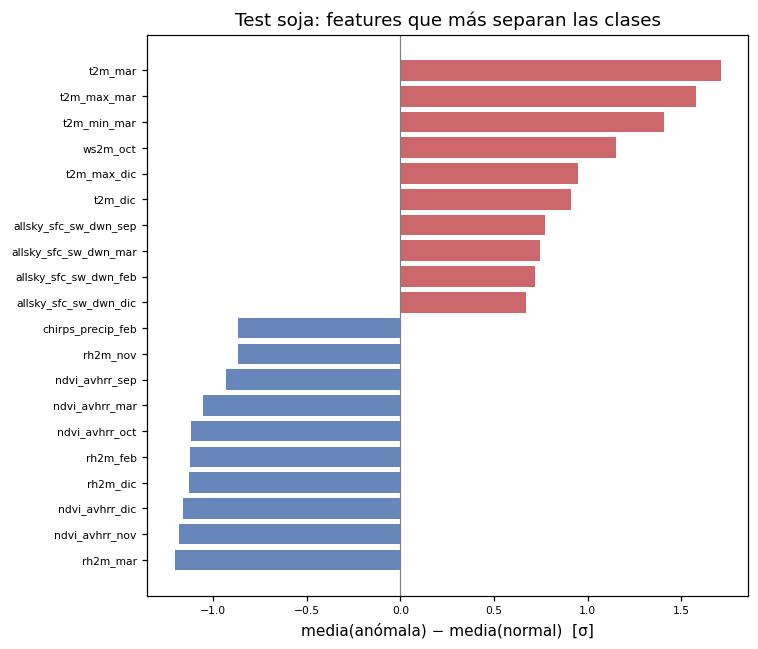

In [6]:
d = ds["soja"]
dif = d.X_test[d.y_test == 1].mean(axis=0) - d.X_test[d.y_test == 0].mean(axis=0)
s = pd.Series(dif, index=d.feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
top = pd.concat([s.head(10), s.tail(10)])
colores = ["#4C72B0" if v < 0 else "#C44E52" for v in top.values]
ax.barh(top.index, top.values, color=colores, alpha=0.85)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("media(anómala) − media(normal)  [σ]")
ax.set_title("Test soja: features que más separan las clases")
ax.tick_params(labelsize=7); plt.tight_layout(); plt.show()

La firma es la de una **sequía con calor**: humedad relativa y precipitación por
debajo (azul), temperaturas y radiación por encima (rojo), acentuándose hacia el final
del verano (marzo, hasta ~1.7σ). Ojo con la lectura: es la separación **en promedio**
sobre un test dominado por la sequía 2022/23 — las distribuciones individuales se
solapan, y esa es exactamente la brecha que documentan los experimentos (las anomalías
sin esta firma son el techo estructural, `experiments/05`).

## 5 · Resumen
- Matrices sin NaN/Inf, normalización correcta (train ≈ N(0,1) por depto).
- Train normal-only con exclusiones documentadas (incluye el bloque de val plegado).
- Shift real train→test tanto en tasa base como en las features → decisiones de
  evaluación de `experiments/01`.
- La señal disponible es la firma de sequía-con-calor del verano; su solapamiento
  caso a caso explica el techo estructural de `experiments/05`.